<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Introduction" data-toc-modified-id="Introduction-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Introduction</a></span></li><li><span><a href="#NLTK-Installation" data-toc-modified-id="NLTK-Installation-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>NLTK Installation</a></span></li><li><span><a href="#Python:-Reading-a-file" data-toc-modified-id="Python:-Reading-a-file-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Python: Reading a file</a></span></li><li><span><a href="#Python-stop-time" data-toc-modified-id="Python-stop-time-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Python stop time</a></span></li><li><span><a href="#Python:-Filter-lists" data-toc-modified-id="Python:-Filter-lists-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Python: Filter lists</a></span></li><li><span><a href="#Basic-Corpus-Functions" data-toc-modified-id="Basic-Corpus-Functions-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Basic Corpus Functions</a></span><ul class="toc-item"><li><span><a href="#Counting-Characters" data-toc-modified-id="Counting-Characters-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Counting Characters</a></span></li><li><span><a href="#Counting-Words" data-toc-modified-id="Counting-Words-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Counting Words</a></span></li><li><span><a href="#Python:-Counters" data-toc-modified-id="Python:-Counters-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Python: Counters</a></span></li><li><span><a href="#Word-analysis" data-toc-modified-id="Word-analysis-6.4"><span class="toc-item-num">6.4&nbsp;&nbsp;</span>Word analysis</a></span></li></ul></li><li><span><a href="#Corpus-Reader" data-toc-modified-id="Corpus-Reader-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Corpus Reader</a></span></li><li><span><a href="#Wikipedia-XML-Corpus" data-toc-modified-id="Wikipedia-XML-Corpus-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Wikipedia XML Corpus</a></span></li><li><span><a href="#Stopwords" data-toc-modified-id="Stopwords-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Stopwords</a></span></li><li><span><a href="#Wordclouds" data-toc-modified-id="Wordclouds-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>Wordclouds</a></span></li><li><span><a href="#Exercises" data-toc-modified-id="Exercises-11"><span class="toc-item-num">11&nbsp;&nbsp;</span>Exercises</a></span></li></ul></div>

# Introduction

This notebook is an introduction to the Natural Language ToolKit (NLTK) and explains some useful Python functions in this context. It can be found in the Nextcloud material folder of the course. It uses parts of the first 2 chapters of the NLTK Book and extends it in some ways. It is inspired by a notebook from Eric Lease Morgan, see https://www3.nd.edu/~emorgan/ . Links in this Jupyter Notebook (JNB) were last visited on 23-04-29. If you find a broken link, please inform the professor.

When learning with the notebook, we will use a shorter german text, that could have a better preprocessing. As a better preprocessed english text you may replace the german file `fontane_briest_1896-2.txt` with `walden.txt`.

At the end there are exercises where you shall apply the learned functions to a bigger german (english student group) or other non-english (german student group) corpus.


#  NLTK Installation

NLTK is installed as usual as a package with `pip`. 

~~~~
# from the command line execute
pip install nltk
~~~~

Since it consists of a lot of files, NLTK has an own download mechanism for managing them. The following command opens a graphical user interface to manage them.

~~~~
# in Python runtime execute
>>> import nltk
>>> nltk.download()
~~~~

# Python: Reading a file

A corpus can be read either by opening a text file with Python or with NLTK classes called CorpusReader. We will start with plain Python. It has a built-in function `open()` (see https://docs.python.org/3/library/functions.html)

One problem may be the coding of the characters in the file. Unicode is an often used coding. A detailled description of how Python handles Unicode can be found here:

https://docs.python.org/3/howto/unicode.html

A simple example for opening a file for reading is:

~~~~
f = open( FILE, 'r')
data   = f.read() # read full content of file
# alternative: read file line by line
# for line in f:
#    do_something(line)
print( data )
~~~~

Also, it is possible to work with the content of an open file using the `with` statement (also see https://docs.python.org/3/reference/compound_stmts.html):

~~~~
myfile = './textfile.txt'
with open(myfile) as f:
	read_data = f.read() # read full content of file
	lines = set(read_data.splitlines()) # create a list of lines in file
    # alternative: read file line by line
    # for line in f:
    #    do_something(line)
~~~~

Here is an example using Unicode, so you can test the functions. Please notice, that the text file has to be in the same folder as the notebook. You may play with 2 files:

* `walden.txt` as an english text
* `fontane_briest_1896-2.txt` as a german text that was not prepared. It it taken from https://dwds.de/ (visited 20/06/06)

or

http://www.deutschestextarchiv.de

http://www.deutschestextarchiv.de/book/show/fontane_briest_1896

In [18]:
import os
import urllib.request
import nltk
nltk.download('stopwords')

# URLs for the texts (using Project Gutenberg as a reliable source for raw text)
text_files = {
    'walden.txt': 'https://www.gutenberg.org/cache/epub/205/pg205.txt',
    # Note: Deutsches Textarchiv has bot protection, so providing a Gutenberg alternative for Fontane
    'fontane_briest_1896.txt': 'https://www.gutenberg.org/cache/epub/5323/pg5323.txt'
}

for filename, url in text_files.items():
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        try:
            # Add a User-Agent to avoid some basic HTTP blocks
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
                out_file.write(response.read())
            print(f"Successfully downloaded {filename}")
        except Exception as e:
            print(f"Failed to download {filename}: {e}")
    else:
        print(f"{filename} already exists in the directory.")

walden.txt already exists in the directory.
fontane_briest_1896.txt already exists in the directory.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\timor\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [25]:
# import / require the use of the Toolkit
FILE = 'fontane_briest_1896.txt'
f = open(FILE, encoding='utf-8', mode='r')
text2   = f.read()

# Replace the historical "long s" (ſ) with the modern round "s"
text2 = text2.replace('ſ', 's')

print( text2 )

[0001]

[0002]

[0003]

[0004]

[0005]

[0006]

[0007]

[0008]
Effi Briest
Roman
von
Theodor Fontane

[Abbildung]

Berlin W
F. Fontane & Co.
1896

[0009]
Alle Rechte
besonders das der Übersetzung
vorbehalten


[[1]/0010]
Erstes Kapitel.
In Front des schon seit Kurfürst Georg Wil¬
helm von der Familie von Briest bewohnten Herren¬
hauses zu Hohen-Cremmen fiel heller Sonnenschein
auf die mittagsstille Dorfstraße, während nach der
Park- und Gartenseite hin ein rechtwinklig angebauter
Seitenflügel einen breiten Schatten erst auf einen
weiß und grün quadrierten Fliesengang und dann
über diesen hinaus auf ein großes in seiner Mitte
mit einer Sonnenuhr und an seinem Rande mit
Canna indica und Rhabarberstauden besetztes Rondell
warf. Einige zwanzig Schritte weiter, in Richtung
und Lage genau dem Seitenflügel entsprechend, lief
eine, ganz in kleinblättrigem Epheu stehende, nur an
einer Stelle von einer kleinen weiß gestrichenen Eisen¬
thür unterbrochene Kirchhofsmauer, hinter der der
Ho

In [26]:
from nltk import *

thewords = word_tokenize( text2 )

print(thewords)

['[', '0001', ']', '[', '0002', ']', '[', '0003', ']', '[', '0004', ']', '[', '0005', ']', '[', '0006', ']', '[', '0007', ']', '[', '0008', ']', 'Effi', 'Briest', 'Roman', 'von', 'Theodor', 'Fontane', '[', 'Abbildung', ']', 'Berlin', 'W', 'F.', 'Fontane', '&', 'Co.', '1896', '[', '0009', ']', 'Alle', 'Rechte', 'besonders', 'das', 'der', 'Übersetzung', 'vorbehalten', '[', '[', '1', ']', '/0010', ']', 'Erstes', 'Kapitel', '.', 'In', 'Front', 'des', 'schon', 'seit', 'Kurfürst', 'Georg', 'Wil¬', 'helm', 'von', 'der', 'Familie', 'von', 'Briest', 'bewohnten', 'Herren¬', 'hauses', 'zu', 'Hohen-Cremmen', 'fiel', 'heller', 'Sonnenschein', 'auf', 'die', 'mittagsstille', 'Dorfstraße', ',', 'während', 'nach', 'der', 'Park-', 'und', 'Gartenseite', 'hin', 'ein', 'rechtwinklig', 'angebauter', 'Seitenflügel', 'einen', 'breiten', 'Schatten', 'erst', 'auf', 'einen', 'weiß', 'und', 'grün', 'quadrierten', 'Fliesengang', 'und', 'dann', 'über', 'diesen', 'hinaus', 'auf', 'ein', 'großes', 'in', 'seiner', 'Mi

# Python stop time

With big corpus it is often useful to do time measurements and print status output. This may look like this:

~~~~
from timeit import default_timer as timer
start = timer()
# do time-consuming operation
end = timer()
print("Operated %s seconds" % (end-start))
~~~~

# Python: Filter lists

There are several ways to filter a list in Python. One way is to keep the items in the list if they fulfill a property:

~~~~
words = ['Hello', 'this', 'is', 'a', 'wordlist' 'with', '7', 'words']
# Lowercase all words of list
words = [word.lower() for word in words]
# Remove numbers
words = [word for word in words if not word.isnumeric()]
~~~~

The second way is to apply a (nameless) function on every item in the list. If the function returns true, the item is kept in the list.

~~~~
wordfilter = filter(lambda w: not w.isnumeric(), words) # create a filter for the list words with lambda function
words = list(wordfilter) # apply filter and return a list
~~~~

Please try it:

In [27]:
words = ['Hello', 'this', 'is', 'a', 'wordlist', 'with', '7', 'words']
# Lowercase all words of list
words = [word.lower() for word in words]
# Remove numbers
wordfilter = filter(lambda w: not w.isnumeric(), words)
words = list(wordfilter)
print(words)

['hello', 'this', 'is', 'a', 'wordlist', 'with', 'words']


# Basic Corpus Functions

## Counting Characters

NLTK comes with some basic functions for counting and statistics. The function `FreqDist()` is quite useful for that.

Typical Python, a filter for choosing characters may be applied directly in the place. The following command filters the alphanumeric characters and creates a frequency distribution of them (line 1). Then the 25 most common characters are printed out with the number of their occurences (line 2). Finally a plot is made of the frequency-distribution. Hint: If you see text describing the plot instead of a graphical view, press execute again.

[('e', 75006), ('n', 48467), ('i', 40271), ('r', 30858), ('s', 30646), ('a', 29614), ('t', 27322), ('h', 27031), ('d', 23456), ('u', 17705), ('c', 17057), ('l', 16638), ('g', 13134), ('m', 12574), ('o', 11328), ('b', 9820), ('w', 9304), ('f', 8703), ('k', 5464), ('z', 4723), ('v', 3365), ('ü', 3169), ('p', 2643), ('ä', 2239), ('ß', 2208)]


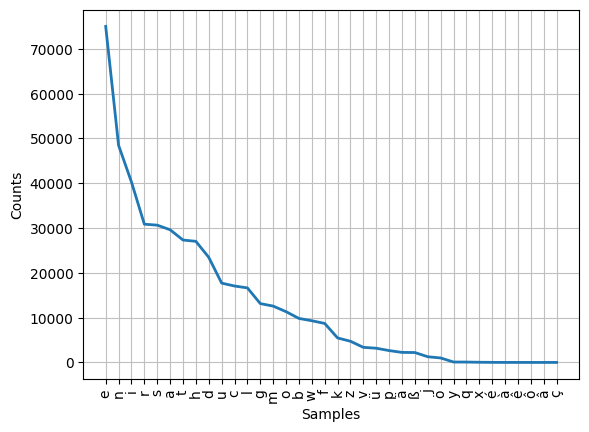

In [28]:
import nltk
import matplotlib
import matplotlib.pyplot as plt

fdist = nltk.FreqDist(ch.lower() for ch in text2 if ch.isalpha())
print(fdist.most_common(25))
plot = fdist.plot()

## Counting Words 

The text string `text2` can be splitted into words using the NLTK function `word_tokenize()`.

`words = word_tokenize( text2 )`

Then it is possible to analyze them in different ways. The following example first prints the most often used words. Then a plot of the 10 most often word lengths is drawn.

[(',', 10339), ('.', 4206), ('und', 3453), ('“', 1907), ('„', 1903), ('die', 1800), ('der', 1425), ('das', 1354), ('ich', 1326), ('nicht', 1321), ('Effi', 1181), ('es', 1169), ('sie', 1128), ('in', 1041), ('so', 1038), ('zu', 1033), ('ist', 957), ('war', 933), ('sich', 872), ('mit', 791)]
counted Küste
2


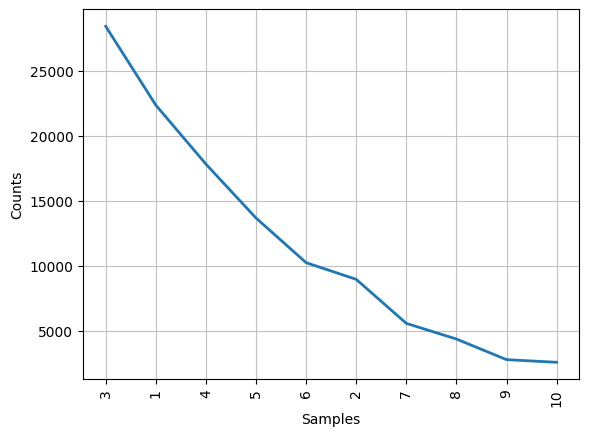

In [29]:
words = word_tokenize( text2 )
lengths = [ len( w ) for w in words ]
wordsfd = FreqDist(words)
print(wordsfd.most_common(20)) # print 20 most often words
theword = 'Küste'
print('counted ' + theword)
print( wordsfd[ 'Küste' ] ) # How often does a word appear in the text?
plot    = FreqDist( lengths ).plot( 10 ) # plot 10 most often word lengths

For a description of the difference between the functions `word()` and `word_tokenize()`: see https://stackoverflow.com/questions/46965585/nltk-words-vs-word-tokenize

The NLTK comes with several tokenizers, see the nltk.tokenize package at https://www.nltk.org/api/nltk.tokenize.html .

The number of words and how often they are used is a measure of the lexical richness of the text. 

~~~~
text1 = corp1.raw() # Corp1 was read with PlaintextCorpusReader

len(set(text1)) / len(text1)
~~~~


## Python: Counters

Using the Python module `collections`, it is possible to count specific words:

~~~~
from collections import Counter

wordcounts = Counter(corp1.words())
wordcounts['Aber']
~~~~


## Word analysis

NGrams may be built to see the contextes in which words are used:

In [30]:
ngrams      = nltk.ngrams( words, 2 )
frequencies = FreqDist( ngrams )
frequencies.most_common( 10 )

[((',', 'und'), 1114),
 (('“', '„'), 993),
 (('Effi', 'Briest'), 520),
 ((',', 'daß'), 515),
 ((']', 'Effi'), 485),
 ((',', 'die'), 453),
 (('.', '„'), 445),
 ((',', 'das'), 421),
 (('.', 'Und'), 409),
 (('.', 'Aber'), 327)]

The class `Text` in the module `text` can be used to explore more aspects of words, see https://www.nltk.org/api/nltk.html?highlight=text#nltk.text.Text


In [31]:
# do keyword-in-context searching against the text (concordancing)
text2     = Text( words )
print (text2)
print( text2.concordance( 'Liebe' ) )

<Text: 0001>
Displaying 25 of 105 matches:
 zogenen Übungen mit ganz besonderer Liebe hingab , und wenn sie dann so dastan
ft so 'was Komisches. “ „ Ja , meine Liebe , das haben sie . Dafür sind es eben
s Verlangen gehabt hättest. “ „ Ja , liebe Mama , was soll ich da sagen . Ei¬ g
t Du . Ich weiß es wohl . Aber meine liebe Effi , wir müssen vorsichtig im Lebe
 natürlich auch für Zärtlichkeit und Liebe . Und wenn es Zärtlichkeit und Liebe
Liebe . Und wenn es Zärtlichkeit und Liebe nicht sein können , weil Liebe , wie
t und Liebe nicht sein können , weil Liebe , wie Papa sagt , doch nur ein Pappe
Mama , das ist mein völliger Ernst . Liebe kommt zuerst , aber gleich hinterher
nnst . Freilich , wenn im Winter die liebe Verwandtschaft [ 47/0056 ] Effi Brie
a auch Landrat. “ „ Lies , lies. “ „ Liebe Effi … “ So fängt es nämlich immer a
. “ [ 48/0057 ] Effi Briest „ Also : Liebe Effi ! Je näher wir unsrem Hochzeits
 rechte Maß , das hält er. “ „ Meine liebe Effi , laß mich eine Frage thun ; 

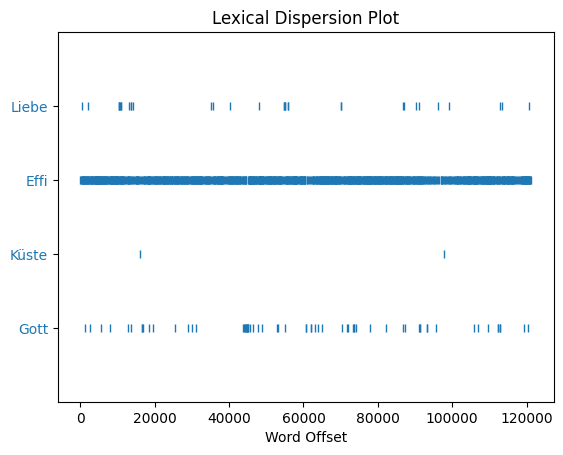

In [32]:
# create a dispersion plot of given words
plot = text2.dispersion_plot( [ 'Liebe', 'Effi', 'Küste', 'Gott' ] )

In [33]:
# output the "most significant" bigrams, considering surrounding words (size of window) -- season to taste
print( text2 )
print(text2.collocations( num=10, window_size=4 ))
text2.collocations(  )
# collocation_list() returns a list of tuples (e.g. [('hello', 'world')]), so we must join the tuples into strings first 
print('; '.join([' '.join(col) for col in text2.collocation_list()]))

<Text: 0001>
Effi Briest; Inn¬ stetten; gnädigste Frau; mit dem; Und nun; Und dann;
meine gnädigste; gnäd'ge Frau; ich mich; Ich habe
None
Effi Briest; mit dem; gnädigste Frau; Inn¬ stetten; Und nun; Und dann;
das ist; auf dem; Das ist; Ich habe; ein paar; gnäd'ge Frau; wenn ich;
daß ich; meine gnädigste; denn auch; auf den; diesem Augenblicke; mit
einem; gar nicht
Effi Briest; mit dem; gnädigste Frau; Inn¬ stetten; Und nun; Und dann; das ist; auf dem; Das ist; Ich habe; ein paar; gnäd'ge Frau; wenn ich; daß ich; meine gnädigste; denn auch; auf den; diesem Augenblicke; mit einem; gar nicht


The function common_contexts finds contexts where the specified words can all appear. It returns a frequency distribution mapping each context to the number of times that context was used.

In [38]:
# given a set of words, what words are nearby
text2.common_contexts( ['herr', 'Briest'], 200)

wieder_und


In [39]:
# list the words (features) most associated with the given word
text2.similar( 'herr', 20 )

der frau major doktor die dann eine alte sich ging „ innstetten baron
oben mann morgen gieshübler küche fürst sand



# Corpus Reader

NLTK has several classes for reading different types of text files. The classes contain methods for working with the corpus.

https://www.nltk.org/howto/corpus.html

https://www.nltk.org/_modules/nltk/corpus/reader/xmldocs.html

First, the directory where the corpus is stored has to be defined.

Then the corpus can be read using the constructor of the CorpusReader.

The CorpusReader has to be imported from the module nltk.corpus

One CorpusReader is the `PlaintextCorpusReader` which can be used for text files.

Another is the `XMLcorpusReader`. Both can be used in a similar way. As an example here is a XMLCorpusReader:

~~~~
from nltk.corpus import XMLCorpusReader
corpus_root = './data' # a subdirectory called data is used to store the corpus file
corp1 = XMLCorpusReader(corpus_root, 'dewiki-latest-abstract1.xml')
~~~~
After the corpus is opened, you can use functions like `sents()` and `words()` to split the corpus into sentences or words. 


# Wikipedia XML Corpus

Wikipedia offers its content as an XML-Corpus. It can be read in the usual way and the NLTK functions may be applied as well. 

download from https://dumps.wikimedia.org/dewiki/latest/ (visited 23-04-29), e.g. dewiki-latest-abstract1.xml.gz                     27-May-2020 02:35  size:          83327396

Just extract it to get an XML file which can be read by the corpus reader.



# Stopwords

from NLTK Book Chapter 2:

" stopwords, that is, high-frequency words like the, to and also that we sometimes want to filter out of a document before further processing. Stopwords usually have little lexical content, and their presence in a text fails to distinguish it from other texts."

The NLTK has a list of own stopwords. One may add an own additional list of stopwords to create a compound list.

These steps could look like this:

~~~~
# use stopwords from NLTK
default_stopwords = set(stopwords.words('german'))
# read additional stopwords from file
stopwords_file = './stopwords.txt'
with open(stopwords_file) as f:
	read_data = f.read()
	custom_stopwords = set(read_data.splitlines())
# bundle both sources for all_stopwords
all_stopwords = default_stopwords | custom_stopwords

print(all_stopwords)
~~~~

also see https://www.strehle.de/tim/weblog/archives/2015/09/03/1569 (visited 23-04-29)




In [41]:
from nltk.corpus import stopwords
import os

# use stopwords from NLTK
default_stopwords = set(stopwords.words('german'))
# read additional stopwords from file (only if it exists)
stopwords_file = './stopwords.txt'
custom_stopwords = set()

if os.path.exists(stopwords_file):
    with open(stopwords_file) as f:
        read_data = f.read()
        custom_stopwords = set(read_data.splitlines())
        
# bundle both sources for all_stopwords
all_stopwords = default_stopwords | custom_stopwords

print(all_stopwords)

{'also', 'das', 'waren', 'jener', 'wieder', 'hier', 'sonst', 'derer', 'mein', 'seines', 'will', 'aber', 'viel', 'jetzt', 'was', 'hin', 'seinem', 'jenes', 'wirst', 'man', 'und', 'während', 'ihren', 'können', 'gegen', 'solche', 'doch', 'meinen', 'wenn', 'dazu', 'manches', 'indem', 'unsere', 'einigen', 'aller', 'er', 'muss', 'sie', 'alles', 'dieser', 'soll', 'manchem', 'von', 'jede', 'einen', 'jenem', 'haben', 'dem', 'deinen', 'einig', 'um', 'eurer', 'welchem', 'es', 'bis', 'mancher', 'euren', 'nicht', 'mich', 'allem', 'als', 'eures', 'solches', 'den', 'denselben', 'im', 'zu', 'oder', 'ist', 'anderer', 'eine', 'demselben', 'euch', 'hab', 'würden', 'damit', 'unseres', 'jeden', 'denn', 'hinter', 'einer', 'vor', 'keinem', 'ihre', 'dies', 'daß', 'dort', 'meiner', 'der', 'solchem', 'welcher', 'so', 'werden', 'unseren', 'in', 'jenen', 'machen', 'ein', 'meinem', 'weiter', 'nichts', 'desselben', 'manchen', 'ob', 'selbst', 'ihnen', 'dasselbe', 'deine', 'anderes', 'etwas', 'meine', 'keines', 'diese


# Wordclouds

Instead of using frequency distributions it is also useful to generate wordclouds in order to get an idea of the most often used words in a text. Also see https://github.com/sqlshep/SQLShepBlog/blob/master/Python/HR1%20NLTK/NLTK%20HR1.ipynb (visited 23-04-29)

Please install the package to use it later in the exercises.




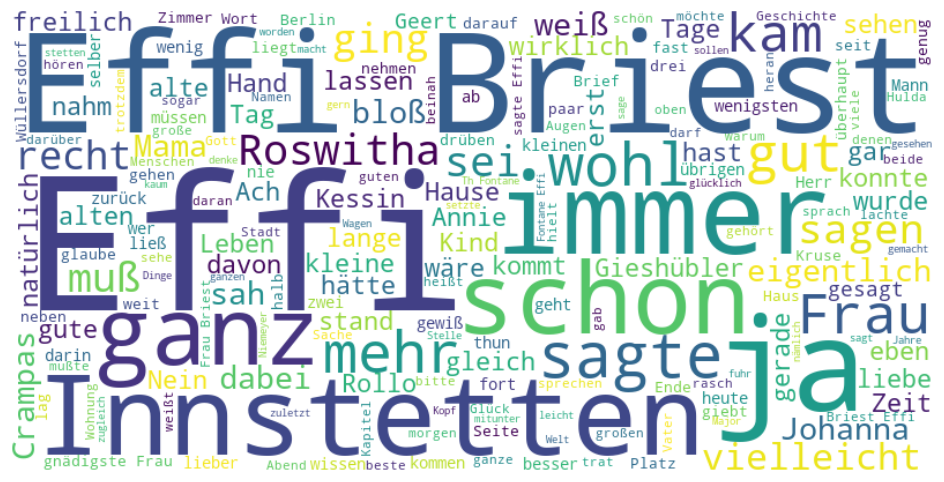

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# We use the tokenized words from earlier, filtering out the stopwords 
# (which we defined in the previous cell) and any non-alphabetic punctuation.
cleaned_words = [w for w in thewords if w.isalpha() and w.lower() not in all_stopwords]
text_for_cloud = ' '.join(cleaned_words)

# Generate the wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_cloud)

# Display the generated image
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide the axes
plt.show()


# Exercises (Part of the 'Leistungsnachweis')

## Introduction

The aim of this exercise is to analyze a big corpus German or another language, which is not English. If you want to choose another language, it must have Latin characters. Send an e-mail to the professor with the language and the corpus URL. 

Start with the creation of a Jupyter Notebook (JNB, ipynb file) for your answers to the following questions. Graphics shall also be included. Export the JNB as a PDF and upload it in iLearn. If you have problems with the JNB, you may alternatively write the answers in a text processor and produce a PDF.

The first chapter of the PDF must contain:

- Your name and Matriculation Number
- The chosen language
- Name and description of the corpus with a link (URL) for download.
- The solutions to the tasks described in the next section.

## Task List

1) Install the needed packages NLTK, matplotlib, wordcloud. Choose the language you want to analyze. Check whether NLTK supports this language.

2) Install other language packages of NLTK and corpora if necessary.

3) Choose a large corpus (at least 1M, better 10 MB, e.g. Wikipedia, Twitter, see slides spr-04-corpus-words.pdf) that is available in the chosen language. Load it in NLTK and use it for the following exercises. Please inform the lecturer about the chosen corpus via e-mail.

Important: Depending on the corpus, you often have to do a preprocessing step before you continue doing the following tasks. Preprocessing may include case-folding, removing line-numbers or other characters, etc.

4) Calculate the lexical richness of the selected corpus.

5) Plot the character distribution of your selected corpus.

6) Plot the word distribution of the 20 most often used words of your selected corpus (with stopwords).

7) Plot the dispersion plot of the 5 most often used words.

8) Find the longest word in the text. Select an algorithm for splitting words (also called word break / split algorithm) and split the word into subwords.

9) Find a short sentence with 5 words (plus/minus 1). Create a context-free grammar for the sentence. The grammar shall show the syntactical structure of the sentence, so the terminal symbols shall be words.

10) PoS tag the words of the sentence with the pos_tag function. What is the result of the `evaluate` function for this sentence?

11) Select a suitable stemmer and stem every word in the sentence found with part 9.

12) Find a lemmatizer for the language and lemmatize every word in the sentence.

13) Remove stopwords and repeat exercises 6+7 (word distribution and dispersion plot).

14) Print a wordcloud without your stopwords.

